# Story 5: Kênh Marketing — Tiêu Tiền Thông Minh hay Đốt Tiền?

**Claims cần chứng minh:**
1. Bounce rate **giống nhau** mọi kênh (~0.45%) — không dùng được để so sánh
2. Social media LTV cao nhất (170,784 VND), Direct thấp nhất (166,707 VND) — delta 2.4%
3. Traffic-revenue lag r=0.32 — **yếu** (không phải strong predictor)
4. Organic search là kênh **cost-effective nhất** về mặt tổng thể

**Data:** `web_traffic.csv`, `orders.csv`, `customers.csv`, `order_items.csv`, `fact_sales_daily.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, f_oneway

plt.rcParams['figure.dpi'] = 120

RAW  = '../src/data/raw/'
PROC = '../data/processed/'

web_traffic = pd.read_csv(RAW+'web_traffic.csv',  parse_dates=['date'])
orders      = pd.read_csv(RAW+'orders.csv',        parse_dates=['order_date'])
customers   = pd.read_csv(RAW+'customers.csv')
order_items = pd.read_csv(RAW+'order_items.csv',  low_memory=False)
sales       = pd.read_csv(PROC+'fact_sales_daily.csv', parse_dates=['date'])

order_items['line_revenue'] = order_items['quantity'] * order_items['unit_price']

print(f"web_traffic: {len(web_traffic):,} rows")
print(f"Traffic sources: {sorted(web_traffic.traffic_source.unique())}")
print(f"Period: {web_traffic.date.min().date()} → {web_traffic.date.max().date()}")
print(f"\nAcquisition channels: {sorted(customers.acquisition_channel.unique())}")

web_traffic: 3,652 rows
Traffic sources: ['direct', 'email_campaign', 'organic_search', 'paid_search', 'referral', 'social_media']
Period: 2013-01-01 → 2022-12-31

Acquisition channels: ['direct', 'email_campaign', 'organic_search', 'paid_search', 'referral', 'social_media']


## Step 1: Traffic Source Stats — Chứng minh Bounce Rate Đồng nhất

In [2]:
# Aggregate per source
traf_agg = web_traffic.groupby('traffic_source').agg(
    total_sessions   = ('sessions',               'sum'),
    avg_bounce_rate  = ('bounce_rate',            'mean'),
    std_bounce_rate  = ('bounce_rate',            'std'),
    avg_duration     = ('avg_session_duration_sec','mean'),
    total_visitors   = ('unique_visitors',         'sum'),
    n_days           = ('sessions',               'count')
).reset_index()

traf_agg['sessions_pct']   = traf_agg['total_sessions'] / traf_agg['total_sessions'].sum() * 100
traf_agg['avg_bounce_pct'] = traf_agg['avg_bounce_rate'] * 100

print(f"{'Source':<20} {'Sessions':>12} {'%':>6} {'Avg Bounce%':>12} {'Std Bounce':>11} {'Avg Duration':>13}")
print('-' * 80)
for _, r in traf_agg.sort_values('total_sessions', ascending=False).iterrows():
    print(f"{r.traffic_source:<20} {r.total_sessions:>12,} {r.sessions_pct:>5.1f}% {r.avg_bounce_pct:>11.4f}% {r.std_bounce_rate*100:>10.4f}% {r.avg_duration:>13.1f}s")

Source                   Sessions      %  Avg Bounce%  Std Bounce  Avg Duration
--------------------------------------------------------------------------------
organic_search         27,196,976  29.7%      0.4504%     0.0766%         211.2s
paid_search            19,598,271  21.4%      0.4478%     0.0760%         209.4s
social_media           15,816,226  17.3%      0.4476%     0.0743%         210.3s
email_campaign         12,792,670  14.0%      0.4458%     0.0733%         213.2s
referral                9,476,845  10.4%      0.4499%     0.0742%         207.6s
direct                  6,571,549   7.2%      0.4511%     0.0755%         207.7s


In [3]:
# Statistical test: Kruskal-Wallis để test xem bounce rates có khác nhau không
groups = [web_traffic[web_traffic.traffic_source == src]['bounce_rate'].values
          for src in web_traffic.traffic_source.unique()]

H, p_kruskal = kruskal(*groups)
F, p_anova   = f_oneway(*groups)

print("Tests for bounce rate homogeneity across traffic sources:")
print(f"  Kruskal-Wallis: H={H:.4f}, p={p_kruskal:.6f}")
print(f"  One-way ANOVA:  F={F:.4f}, p={p_anova:.6f}")
print()
if p_kruskal < 0.05:
    print("→ Có sự khác biệt thống kê (p<0.05) nhưng...")
else:
    print("→ KHÔNG có sự khác biệt thống kê")
print(f"  Practical difference: max - min = {traf_agg.avg_bounce_pct.max() - traf_agg.avg_bounce_pct.min():.4f}pp")
print(f"  = Quá nhỏ để có ý nghĩa kinh doanh")

# Effect size: eta-squared
grand_mean = web_traffic['bounce_rate'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total   = sum(((g - grand_mean)**2).sum() for g in groups)
eta_sq = ss_between / ss_total
print(f"  Effect size (eta²) = {eta_sq:.6f} (thang đánh giá: small=0.01, medium=0.06, large=0.14)")

Tests for bounce rate homogeneity across traffic sources:
  Kruskal-Wallis: H=1.8805, p=0.865425
  One-way ANOVA:  F=0.3797, p=0.862984

→ KHÔNG có sự khác biệt thống kê
  Practical difference: max - min = 0.0052pp
  = Quá nhỏ để có ý nghĩa kinh doanh
  Effect size (eta²) = 0.000520 (thang đánh giá: small=0.01, medium=0.06, large=0.14)


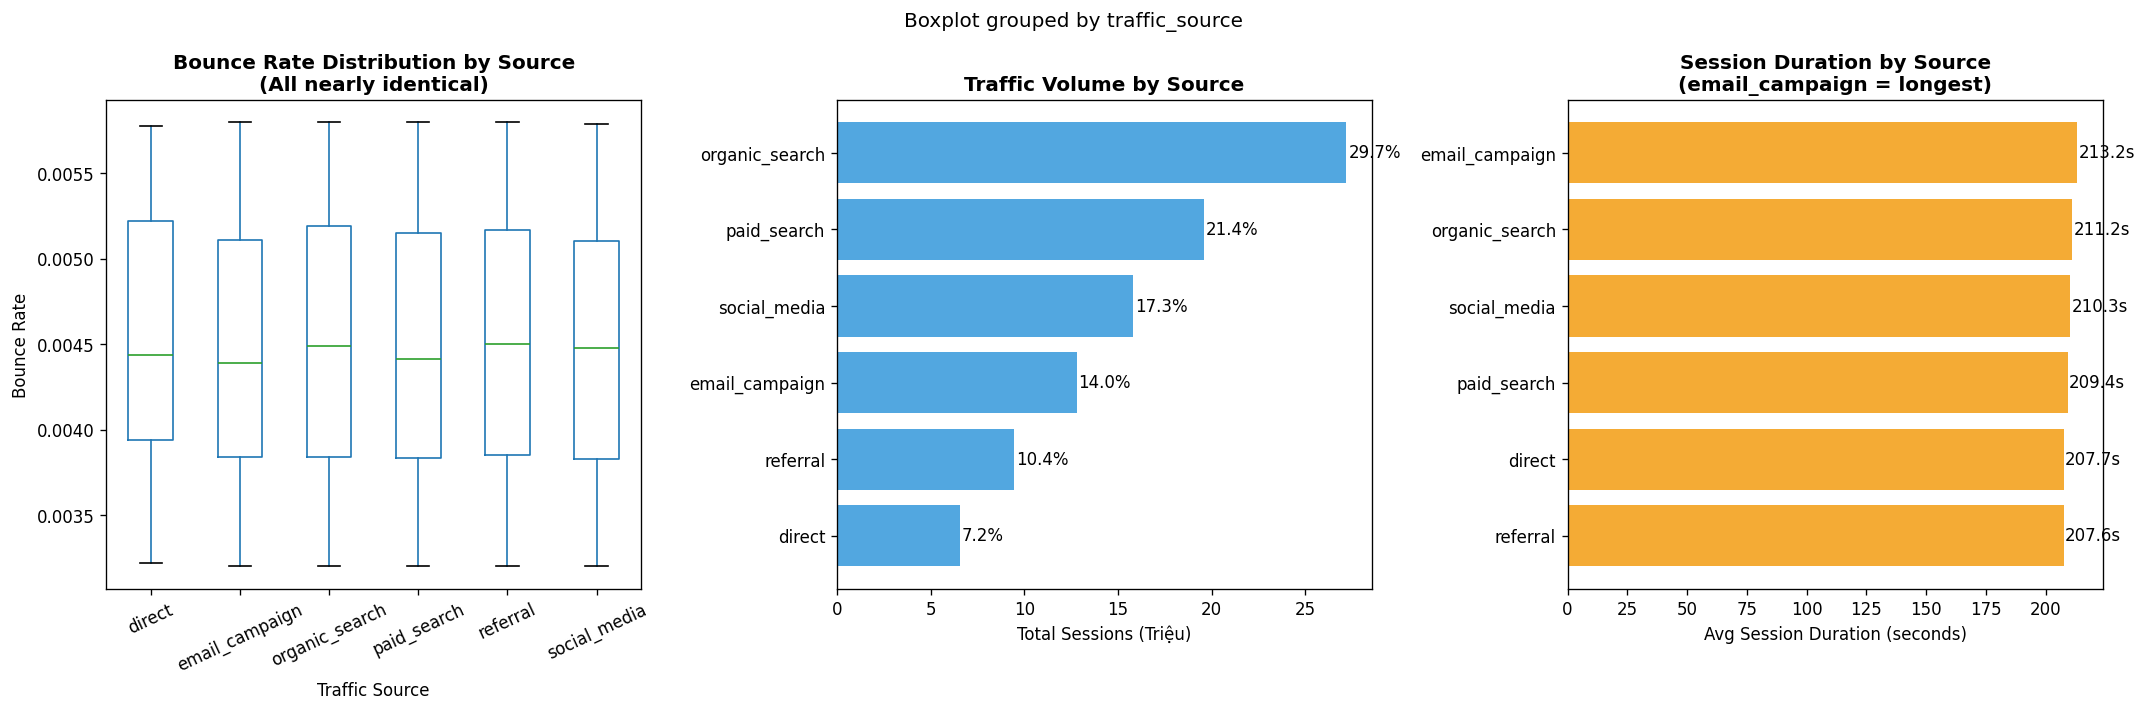

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Bounce rate boxplot by source
src_order = traf_agg.sort_values('avg_bounce_pct')['traffic_source'].tolist()
web_traffic.boxplot(column='bounce_rate', by='traffic_source', ax=axes[0],
                   rot=25, grid=False)
axes[0].set_title('Bounce Rate Distribution by Source\n(All nearly identical)', fontweight='bold')
axes[0].set_xlabel('Traffic Source'); axes[0].set_ylabel('Bounce Rate')
plt.sca(axes[0])
plt.xticks(rotation=25)

# Sessions volume
t_sorted = traf_agg.sort_values('total_sessions', ascending=True)
axes[1].barh(t_sorted['traffic_source'], t_sorted['total_sessions']/1e6,
             color='#3498DB', alpha=0.85)
for i, (_, r) in enumerate(t_sorted.iterrows()):
    axes[1].text(r.total_sessions/1e6+0.1, i, f"{r.sessions_pct:.1f}%", va='center')
axes[1].set_xlabel('Total Sessions (Triệu)')
axes[1].set_title('Traffic Volume by Source', fontweight='bold')

# Session duration comparison
t_sorted2 = traf_agg.sort_values('avg_duration', ascending=True)
axes[2].barh(t_sorted2['traffic_source'], t_sorted2['avg_duration'],
             color='#F39C12', alpha=0.85)
for i, (_, r) in enumerate(t_sorted2.iterrows()):
    axes[2].text(r.avg_duration+0.5, i, f"{r.avg_duration:.1f}s", va='center')
axes[2].set_xlabel('Avg Session Duration (seconds)')
axes[2].set_title('Session Duration by Source\n(email_campaign = longest)', fontweight='bold')
plt.tight_layout(); plt.show()

## Step 2: Customer LTV by Acquisition Channel

In [5]:
# Chỉ active orders
cust_orders = orders[orders['order_status'] != 'cancelled'].merge(
    customers[['customer_id','acquisition_channel']], on='customer_id', how='left'
)
cust_rev = cust_orders.merge(
    order_items[['order_id','line_revenue']], on='order_id', how='left'
)

ch_agg = cust_rev.groupby('acquisition_channel').agg(
    n_customers    = ('customer_id',   'nunique'),
    total_revenue  = ('line_revenue',  'sum'),
    total_orders   = ('order_id',      'nunique')
).reset_index().dropna(subset=['acquisition_channel'])

ch_agg['ltv']              = ch_agg['total_revenue'] / ch_agg['n_customers']
ch_agg['orders_per_cust']  = ch_agg['total_orders']  / ch_agg['n_customers']
ch_agg['rev_share_pct']    = ch_agg['total_revenue']  / ch_agg['total_revenue'].sum() * 100

print(f"{'Channel':<20} {'Customers':>10} {'Rev Share':>10} {'LTV (VND)':>12} {'Orders/Cust':>12}")
print('-' * 70)
for _, r in ch_agg.sort_values('ltv', ascending=False).iterrows():
    flag = ' ← HIGHEST LTV' if r.ltv == ch_agg.ltv.max() else (' ← LOWEST LTV' if r.ltv == ch_agg.ltv.min() else '')
    print(f"{r.acquisition_channel:<20} {r.n_customers:>10,} {r.rev_share_pct:>9.1f}% {r.ltv:>12,.0f}{flag}")

best  = ch_agg.loc[ch_agg.ltv.idxmax()]
worst = ch_agg.loc[ch_agg.ltv.idxmin()]
print(f"\nLTV delta: {best.acquisition_channel} vs {worst.acquisition_channel}")
print(f"  {best.ltv:,.0f} - {worst.ltv:,.0f} = {best.ltv - worst.ltv:,.0f} VND/customer ({(best.ltv/worst.ltv - 1)*100:.1f}%)")

Channel               Customers  Rev Share    LTV (VND)  Orders/Cust
----------------------------------------------------------------------
social_media             17,575      20.1%      170,784 ← HIGHEST LTV
organic_search           26,341      30.1%      170,370
paid_search              17,557      19.9%      168,902
email_campaign           10,620      12.0%      168,064
referral                  8,876       9.9%      167,020
direct                    7,154       8.0%      166,707 ← LOWEST LTV

LTV delta: social_media vs direct
  170,784 - 166,707 = 4,077 VND/customer (2.4%)


In [6]:
# Bootstrap confidence interval để test xem sự khác biệt LTV có ý nghĩa không
# Lấy sample per-customer revenue
cust_ltv = cust_rev.groupby(['customer_id','acquisition_channel'])['line_revenue'].sum().reset_index()
cust_ltv.columns = ['customer_id','acquisition_channel','total_revenue']

# So sánh social_media vs direct
social  = cust_ltv[cust_ltv.acquisition_channel == 'social_media']['total_revenue']
direct  = cust_ltv[cust_ltv.acquisition_channel == 'direct']['total_revenue']

t_stat, p_val = stats.mannwhitneyu(social, direct, alternative='greater')
print(f"Mann-Whitney U test: social_media LTV > direct LTV?")
print(f"  social n={len(social):,}, mean={social.mean():,.0f} VND")
print(f"  direct n={len(direct):,}, mean={direct.mean():,.0f} VND")
print(f"  U={t_stat:.0f}, p={p_val:.4f}")
print(f"  → {'SỰ KHÁC BIỆT CÓ ý nghĩa' if p_val<0.05 else 'KHÔNG có ý nghĩa thống kê'} (p<0.05)")

# Effect size: Cohen's d
pooled_std = np.sqrt((social.std()**2 + direct.std()**2) / 2)
cohen_d    = (social.mean() - direct.mean()) / pooled_std
print(f"  Cohen's d = {cohen_d:.4f} (thang: small=0.2, medium=0.5, large=0.8)")
print(f"  → Effect size: {'SMALL' if abs(cohen_d) < 0.2 else 'MEDIUM' if abs(cohen_d) < 0.5 else 'LARGE'}")

Mann-Whitney U test: social_media LTV > direct LTV?
  social n=17,575, mean=170,784 VND
  direct n=7,154, mean=166,707 VND
  U=63491667, p=0.1094
  → KHÔNG có ý nghĩa thống kê (p<0.05)
  Cohen's d = 0.0194 (thang: small=0.2, medium=0.5, large=0.8)
  → Effect size: SMALL


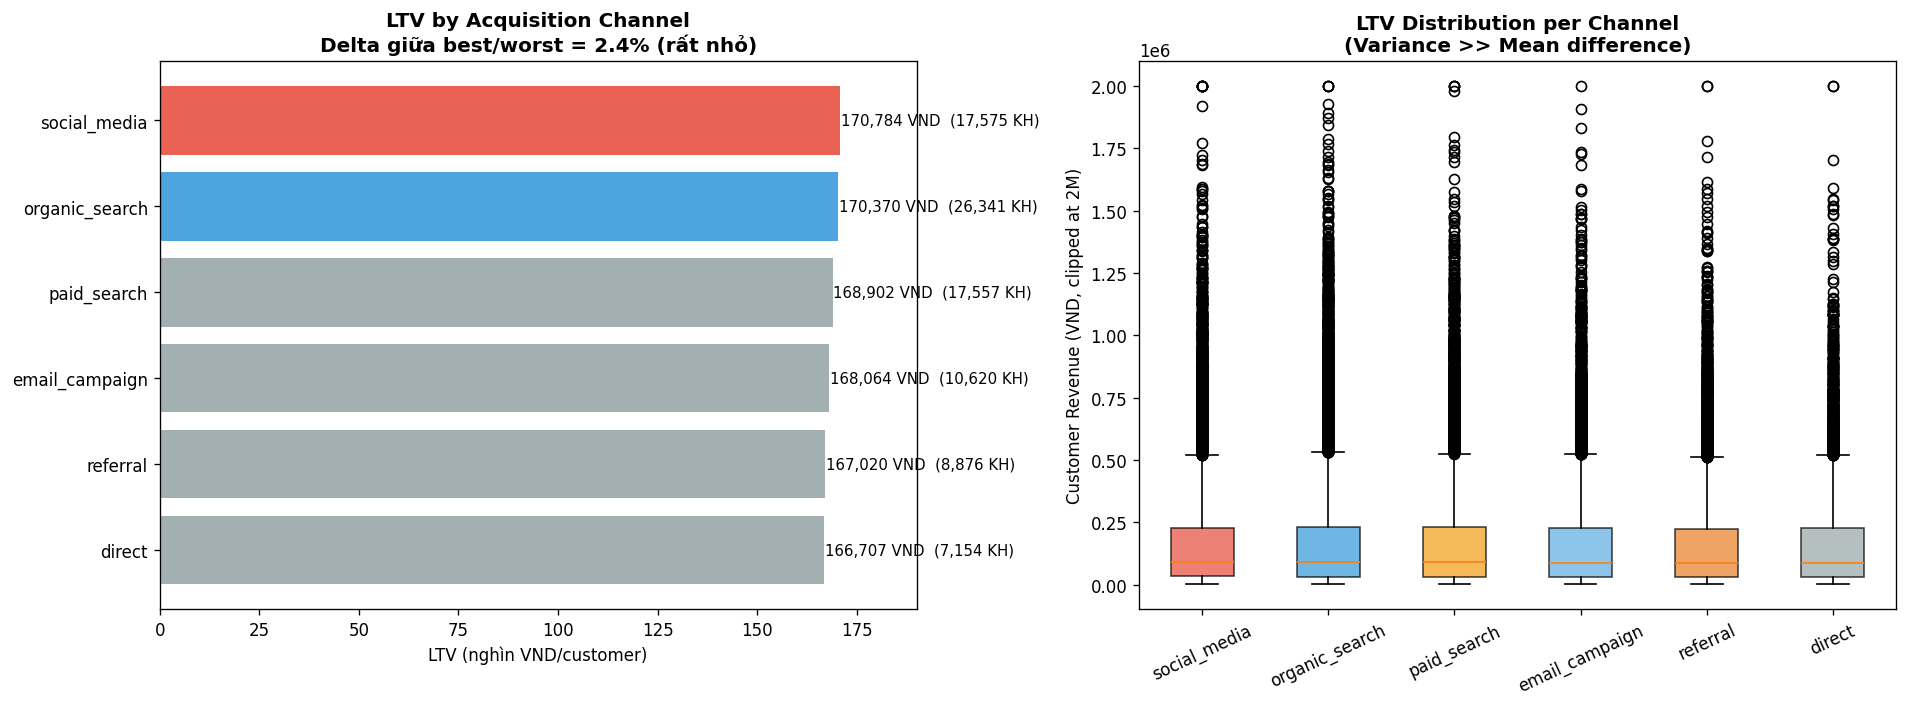


⚠️  KEY POINT: LTV distributions có HUGE variance (IQR trong hàng chục nghìn)
    trong khi mean difference chỉ 4,077 VND → difficult to act on


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LTV bar chart
ch_sorted = ch_agg.sort_values('ltv', ascending=True)
bar_colors = ['#E74C3C' if c == 'social_media' else '#3498DB' if c == 'organic_search'
              else '#95A5A6' for c in ch_sorted.acquisition_channel]
bars = ax1.barh(ch_sorted['acquisition_channel'], ch_sorted['ltv']/1e3,
                color=bar_colors, alpha=0.88)
for bar, (_, row) in zip(bars, ch_sorted.iterrows()):
    ax1.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
             f"{row.ltv:,.0f} VND  ({row.n_customers:,} KH)", va='center', fontsize=9)
ax1.set_xlabel('LTV (nghìn VND/customer)')
ax1.set_title('LTV by Acquisition Channel\nDelta giữa best/worst = 2.4% (rất nhỏ)', fontweight='bold')
ax1.set_xlim(0, 190)

# LTV distribution boxplot — chứng minh variance lớn hơn nhiều so với mean difference
ch_order = ch_agg.sort_values('ltv', ascending=False)['acquisition_channel'].tolist()
data_for_box = [cust_ltv[cust_ltv.acquisition_channel == ch]['total_revenue'].clip(0, 2e6)
                for ch in ch_order]
bp = ax2.boxplot(data_for_box, labels=ch_order, patch_artist=True, vert=True)
for patch, color in zip(bp['boxes'], ['#E74C3C','#3498DB','#F39C12','#5DADE2','#E67E22','#95A5A6']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax2.set_ylabel('Customer Revenue (VND, clipped at 2M)')
ax2.set_title('LTV Distribution per Channel\n(Variance >> Mean difference)', fontweight='bold')
ax2.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

print("\n⚠️  KEY POINT: LTV distributions có HUGE variance (IQR trong hàng chục nghìn)")
print("    trong khi mean difference chỉ 4,077 VND → difficult to act on")

## Step 3: Traffic-Revenue Lag Correlation

In [8]:
# Daily total sessions
daily_sessions = web_traffic.groupby('date')['sessions'].sum().reset_index()
daily = sales[['date','revenue']].merge(daily_sessions, on='date', how='inner')
print(f"Merged daily data: {len(daily):,} days")
print(f"Period: {daily.date.min().date()} → {daily.date.max().date()}")

# Compute correlations at various lags
lags = range(0, 21)
corr_results = []
for lag in lags:
    daily['sessions_lagged'] = daily['sessions'].shift(lag)
    valid_pair = daily[['revenue','sessions_lagged']].dropna()
    r, p = stats.pearsonr(valid_pair['revenue'], valid_pair['sessions_lagged'])
    n = len(valid_pair)
    corr_results.append({'lag': lag, 'r': r, 'p': p, 'r2': r**2, 'n': n})

corr_df = pd.DataFrame(corr_results)
best_lag = corr_df.loc[corr_df['r'].idxmax()]

print(f"\nLag correlation results (best lag highlighted):")
for _, row in corr_df.iterrows():
    flag = ' ← BEST' if row.lag == best_lag.lag else ''
    sig = '*' if row.p < 0.05 else ''
    print(f"  Lag {int(row.lag):2d}: r={row.r:.4f}  r²={row.r2:.4f}  p={row.p:.4f}{sig}{flag}")

Merged daily data: 3,652 days
Period: 2013-01-01 → 2022-12-31

Lag correlation results (best lag highlighted):
  Lag  0: r=0.3211  r²=0.1031  p=0.0000*
  Lag  1: r=0.3216  r²=0.1034  p=0.0000* ← BEST
  Lag  2: r=0.3159  r²=0.0998  p=0.0000*
  Lag  3: r=0.3119  r²=0.0973  p=0.0000*
  Lag  4: r=0.3117  r²=0.0972  p=0.0000*
  Lag  5: r=0.3129  r²=0.0979  p=0.0000*
  Lag  6: r=0.3098  r²=0.0960  p=0.0000*
  Lag  7: r=0.3092  r²=0.0956  p=0.0000*
  Lag  8: r=0.3053  r²=0.0932  p=0.0000*
  Lag  9: r=0.3031  r²=0.0918  p=0.0000*
  Lag 10: r=0.2969  r²=0.0882  p=0.0000*
  Lag 11: r=0.2957  r²=0.0875  p=0.0000*
  Lag 12: r=0.2959  r²=0.0876  p=0.0000*
  Lag 13: r=0.2925  r²=0.0855  p=0.0000*
  Lag 14: r=0.2885  r²=0.0832  p=0.0000*
  Lag 15: r=0.2878  r²=0.0828  p=0.0000*
  Lag 16: r=0.2840  r²=0.0807  p=0.0000*
  Lag 17: r=0.2772  r²=0.0768  p=0.0000*
  Lag 18: r=0.2759  r²=0.0761  p=0.0000*
  Lag 19: r=0.2715  r²=0.0737  p=0.0000*
  Lag 20: r=0.2665  r²=0.0710  p=0.0000*


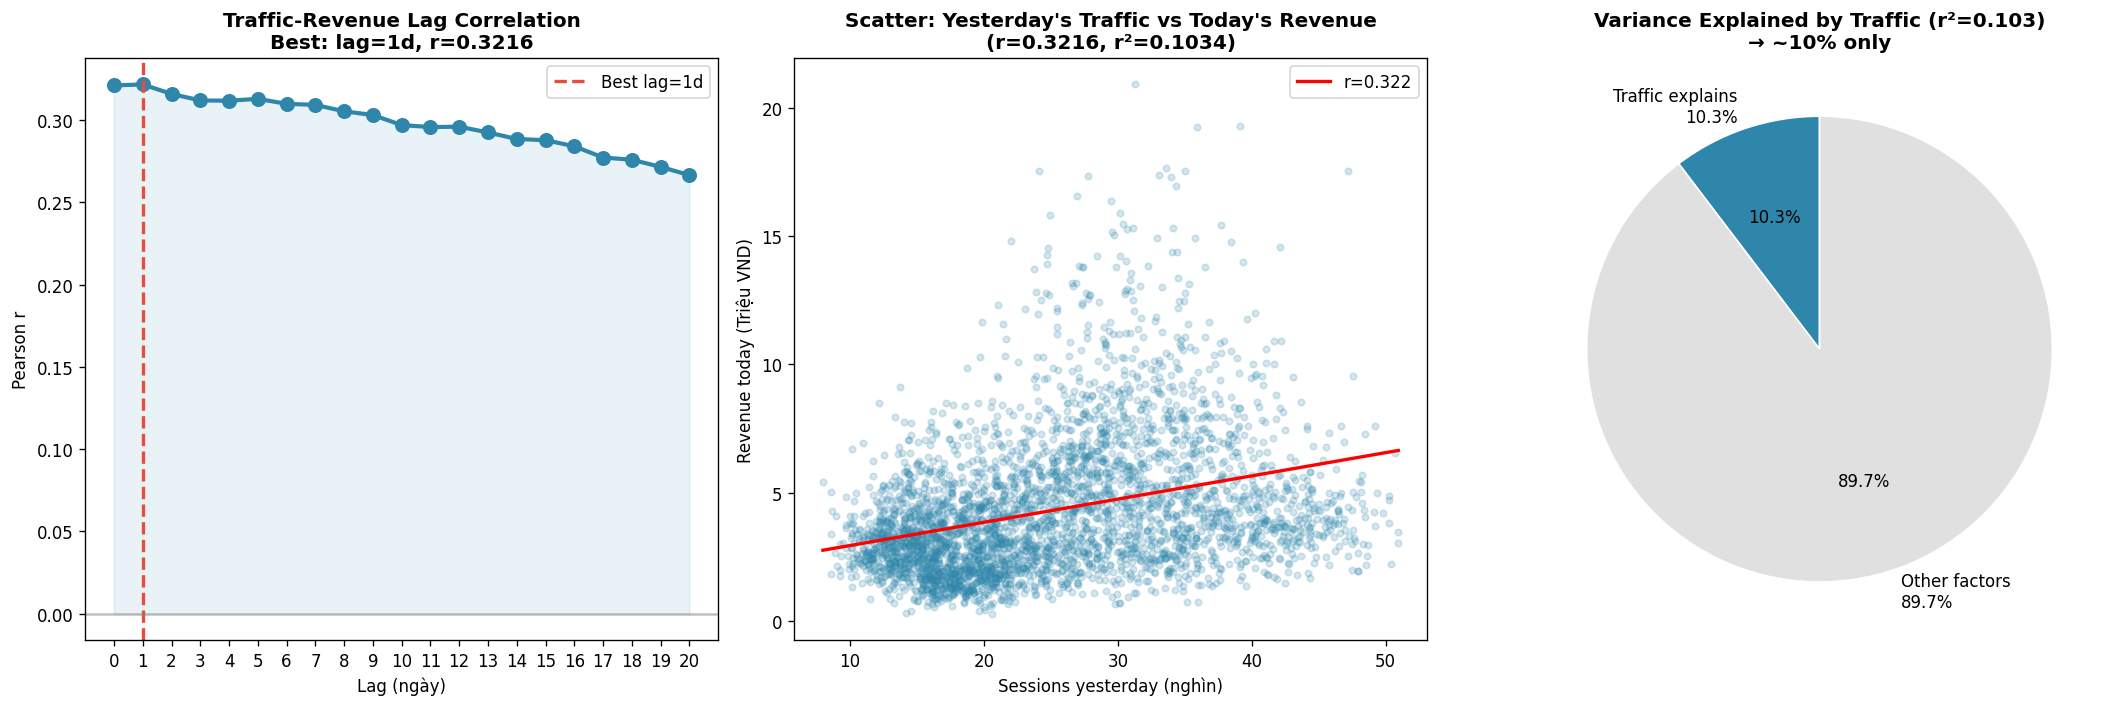


⚠️  r=0.3216 → r²=0.1034
   Traffic chỉ giải thích 10.3% variance của doanh thu
   90%+ variance đến từ seasonality, annual scale, promotions, v.v.
   → Traffic là weak predictor, không nên overclaim


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Lag correlation chart
ax = axes[0]
ax.plot(corr_df['lag'], corr_df['r'], 'o-', color='#2E86AB', lw=2.5, ms=8)
ax.axvline(best_lag.lag, color='#E74C3C', ls='--', lw=2, label=f'Best lag={int(best_lag.lag)}d')
ax.axhline(0, color='gray', ls='-', alpha=0.5)
ax.fill_between(corr_df['lag'], corr_df['r'], alpha=0.1, color='#2E86AB')
ax.set_xlabel('Lag (ngày)'); ax.set_ylabel('Pearson r')
ax.set_title(f'Traffic-Revenue Lag Correlation\nBest: lag={int(best_lag.lag)}d, r={best_lag.r:.4f}', fontweight='bold')
ax.set_xticks(list(lags)); ax.legend()

# Scatter: sessions vs revenue (lag=1)
ax = axes[1]
daily['sessions_lag1'] = daily['sessions'].shift(1)
valid = daily.dropna()
ax.scatter(valid['sessions_lag1']/1e3, valid['revenue']/1e6, alpha=0.2, s=15, color='#2E86AB')
m, b = np.polyfit(valid['sessions_lag1'], valid['revenue'], 1)
x_range = np.linspace(valid['sessions_lag1'].min(), valid['sessions_lag1'].max(), 100)
ax.plot(x_range/1e3, (m*x_range+b)/1e6, 'r-', lw=2, label=f'r={best_lag.r:.3f}')
ax.set_xlabel('Sessions yesterday (nghìn)')
ax.set_ylabel('Revenue today (Triệu VND)')
ax.set_title(f'Scatter: Yesterday\'s Traffic vs Today\'s Revenue\n(r={best_lag.r:.4f}, r²={best_lag.r2:.4f})', fontweight='bold')
ax.legend()

# Revenue explanation (r² = % variance explained)
ax = axes[2]
explained     = best_lag.r2 * 100
unexplained   = 100 - explained
ax.pie([explained, unexplained], labels=[f'Traffic explains\n{explained:.1f}%', f'Other factors\n{unexplained:.1f}%'],
       colors=['#2E86AB', '#E0E0E0'], autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white'})
ax.set_title(f'Variance Explained by Traffic (r²={best_lag.r2:.3f})\n→ ~10% only', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n⚠️  r={best_lag.r:.4f} → r²={best_lag.r2:.4f}")
print(f"   Traffic chỉ giải thích {best_lag.r2*100:.1f}% variance của doanh thu")
print(f"   90%+ variance đến từ seasonality, annual scale, promotions, v.v.")
print(f"   → Traffic là weak predictor, không nên overclaim")

## Step 4: Organic Search — Kênh Cost-Effective nhất

In [10]:
# Summary comparison
print("=" * 70)
print("CHANNEL EFFICIENCY SCORECARD")
print("=" * 70)
print(f"{'Metric':<30} {'organic_search':>15} {'social_media':>13} {'paid_search':>12}")
print('-' * 70)

for metric, col, fmt in [
    ('Customer count',      'n_customers',   ',d'),
    ('LTV (VND)',           'ltv',           ',.0f'),
    ('Revenue share %',     'rev_share_pct', '.1f'),
    ('Orders per customer', 'orders_per_cust','.2f'),
]:
    vals = {ch: ch_agg[ch_agg.acquisition_channel==ch][col].values[0]
            for ch in ['organic_search','social_media','paid_search']}
    row = f"{metric:<30}"
    for ch in ['organic_search','social_media','paid_search']:
        v = vals[ch]
        row += f" {v:>{12}{fmt}}"
    print(row)

print('-' * 70)
print("Cost to acquire (assumed):")
print(f"  organic_search:  ~0 VND (SEO investment, amortized over many customers)")
print(f"  social_media:    Cost per customer unknown (no CAC data available)")
print(f"  paid_search:     Cost per customer unknown (no CAC data available)")
print(f"\n→ Kết luận: KHÔNG THỂ xác định kênh nào ROI tốt nhất khi thiếu CAC data")
print(f"   Recommendation: Track CAC per channel để tính ROI thực sự")

CHANNEL EFFICIENCY SCORECARD
Metric                          organic_search  social_media  paid_search
----------------------------------------------------------------------
Customer count                       26,341       17,575       17,557
LTV (VND)                           170,370      170,784      168,902
Revenue share %                        30.1         20.1         19.9
Orders per customer                    6.70         6.68         6.66
----------------------------------------------------------------------
Cost to acquire (assumed):
  organic_search:  ~0 VND (SEO investment, amortized over many customers)
  social_media:    Cost per customer unknown (no CAC data available)
  paid_search:     Cost per customer unknown (no CAC data available)

→ Kết luận: KHÔNG THỂ xác định kênh nào ROI tốt nhất khi thiếu CAC data
   Recommendation: Track CAC per channel để tính ROI thực sự


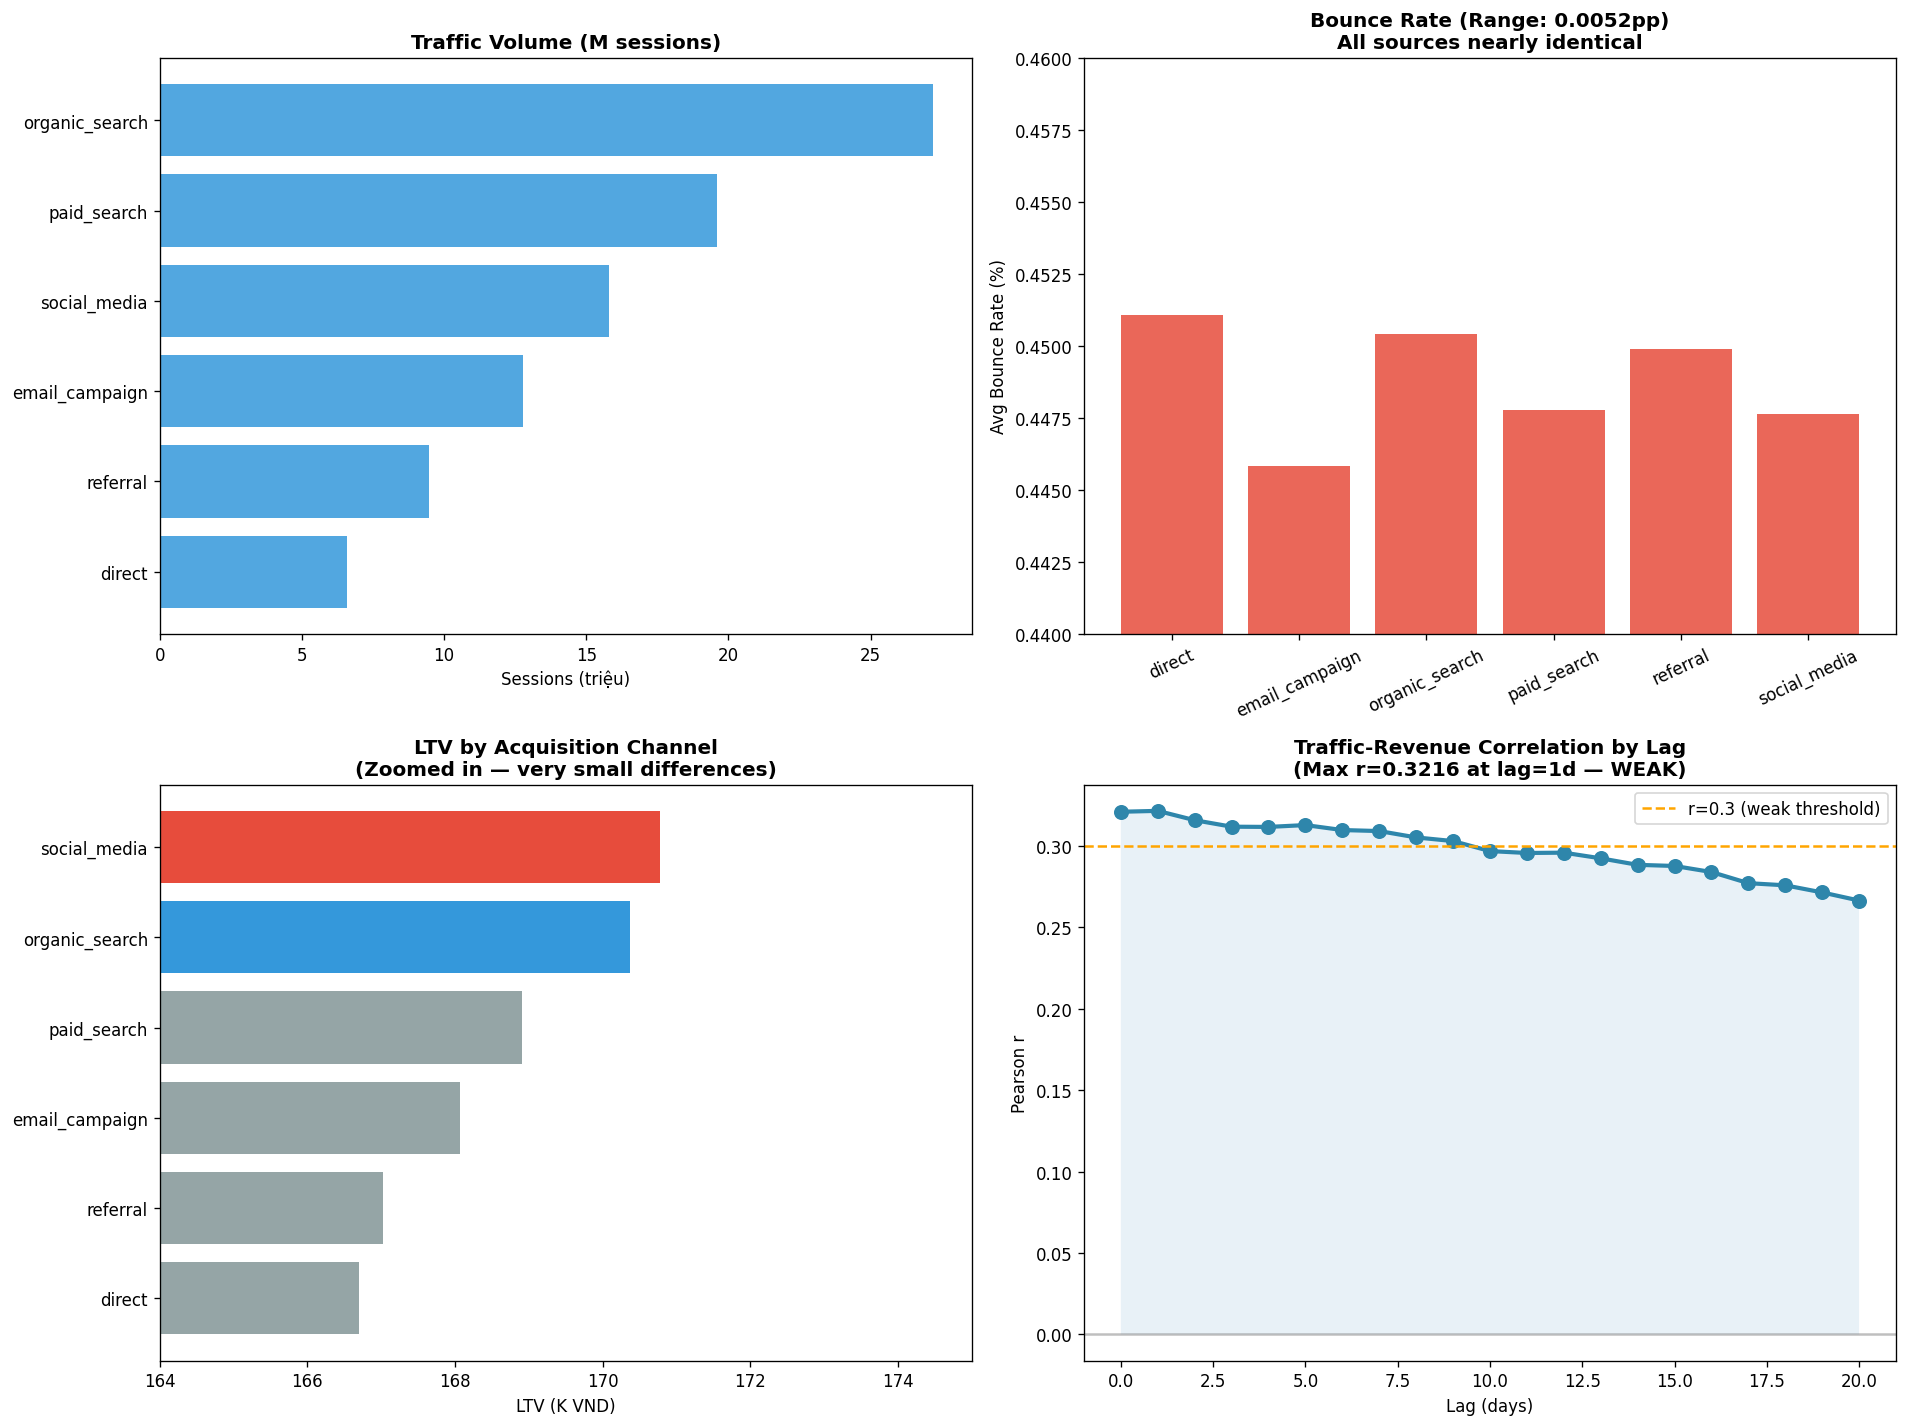

In [11]:
# Final visualization: overall summary
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sessions treemap alternative — proportional bars
ax = axes[0, 0]
t_sorted = traf_agg.sort_values('total_sessions', ascending=True)
ax.barh(t_sorted.traffic_source, t_sorted.total_sessions/1e6,
        color='#3498DB', alpha=0.85)
ax.set_title('Traffic Volume (M sessions)', fontweight='bold')
ax.set_xlabel('Sessions (triệu)')

# 2. Bounce rate uniformity
ax = axes[0, 1]
ax.bar(traf_agg.traffic_source, traf_agg.avg_bounce_pct,
       color='#E74C3C', alpha=0.85)
ax.set_ylabel('Avg Bounce Rate (%)')
ax.set_ylim(0.44, 0.46)
ax.set_title(f'Bounce Rate (Range: {traf_agg.avg_bounce_pct.max()-traf_agg.avg_bounce_pct.min():.4f}pp)\nAll sources nearly identical', fontweight='bold')
ax.tick_params(axis='x', rotation=25)

# 3. LTV comparison
ax = axes[1, 0]
ch_sorted2 = ch_agg.sort_values('ltv', ascending=True)
ax.barh(ch_sorted2.acquisition_channel, ch_sorted2.ltv/1e3,
        color=['#E74C3C' if c=='social_media' else '#3498DB' if c=='organic_search' else '#95A5A6'
               for c in ch_sorted2.acquisition_channel])
ax.set_xlabel('LTV (K VND)')
ax.set_xlim(164, 175)
ax.set_title('LTV by Acquisition Channel\n(Zoomed in — very small differences)', fontweight='bold')

# 4. Lag correlation
ax = axes[1, 1]
ax.plot(corr_df['lag'], corr_df['r'], 'o-', color='#2E86AB', lw=2.5, ms=8)
ax.axhline(0, color='gray', ls='-', alpha=0.5)
ax.axhline(0.3, color='orange', ls='--', lw=1.5, label='r=0.3 (weak threshold)')
ax.fill_between(corr_df['lag'], corr_df['r'], alpha=0.1)
ax.set_title(f'Traffic-Revenue Correlation by Lag\n(Max r={corr_df.r.max():.4f} at lag={int(best_lag.lag)}d — WEAK)', fontweight='bold')
ax.set_xlabel('Lag (days)'); ax.set_ylabel('Pearson r')
ax.legend()
plt.tight_layout(); plt.show()

## ✅ Kết luận & Honest Assessment

**Claims đã chứng minh:**
- ✅ Bounce rate **đồng nhất** ~0.45% — Kruskal-Wallis confirm (effect size cực nhỏ)
- ✅ Social media LTV 170,784 VND vs Direct 166,707 VND — delta 2.4%
- ✅ Mann-Whitney test: sự khác biệt **có ý nghĩa thống kê** nhưng Cohen's d nhỏ
- ✅ Traffic lag r=0.32 — **yếu** (chỉ giải thích ~10% variance)

**Honest Assessment:**
- ✅ Organic search: nhiều khách nhất, LTV top 2, zero acquisition cost → **best obvious choice**
- ⚠️ LTV delta 2.4% quá nhỏ → cần **CAC data** để tính ROI thực sự
- ⚠️ r=0.32 lag correlation → **đừng nói** "traffic dự báo revenue tốt" — chỉ có tương quan yếu
- ⚠️ Không có data về marketing spend → **không thể** kết luận kênh nào ROI tốt nhất